In [ ]:
# conda env create -f env_cmip.yaml   # run if needed, env_cmip.yaml file available with notebooks

In [21]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cftime
from xmip.preprocessing import rename_cmip6
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd



time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
plt.rcParams.update({'font.size': 15})

# Accessing data from CEDA archive through JASMIN jupyter notebooks

In [2]:
all_cents = os.listdir('/badc/cmip6/data/CMIP6/ScenarioMIP/')

all_mods = []
for c in all_cents:
    mods = os.listdir(f'/badc/cmip6/data/CMIP6/ScenarioMIP/{c}/')
    all_mods.append(mods)

len(all_mods)

32

In [3]:

#list centres: scenarioMIP 
cents_list_s2 = os.listdir('/badc/cmip6/data/CMIP6/ScenarioMIP/')

#cant do:
cents_list_s2.remove('HAMMOZ-Consortium') #doesnt have ssp245, only ssp370
#cents_list_s2.remove('CNRM-CERFACS') # s245 only runs until 2020
cents_list_s2.remove('DWD') #doesnt have ssp245 

#hardcode later: 
#cents_list_s2.remove('IPSL') # doesn't have Amon in first model but in second
cents_list_s2.remove('MOHC') #cause hardcoding these two for correct model
cents_list_s2.remove('NCAR') #cause hardcoding these two for correct model

#cents_list_s2.remove('UA') # dimensions are weird 
#cents_list_s2.remove('THU') # values are 1000x smaller than others
#cents_list_s2.remove('EC-Earth-Consortium') # starts 1975: no PI
#cents_list_s2.remove('MIROC')

#list centres: Historic
cents_list_hist = os.listdir('/badc/cmip6/data/CMIP6/CMIP/')


In [4]:
#list models in ScenarioMIP

mods_list_s2 = []
for c in cents_list_s2:
    mods = os.listdir(f'/badc/cmip6/data/CMIP6/ScenarioMIP/{c}/')
    for i in range(len(mods)):
        mods_list_s2.append(mods[i])


#list models in Historical 

mods_list_hist = []
for c in cents_list_hist:
    mods = os.listdir(f'/badc/cmip6/data/CMIP6/CMIP/{c}/')
    for i in range(len(mods)):
        mods_list_hist.append(mods[i])

In [5]:
# make sure s2 and Hist model lists are the same
mods_list = []

for x in range(len(mods_list_s2)):
    if mods_list_s2[x] in mods_list_hist:
        mods_list.append(mods_list_s2[x])

mods_list == mods_list_s2 # hist == s2 + some more


True

In [6]:
# remove some 

# on purpose 
mods_list.remove('MPI-ESM1-2-LR') # cause there twice
mods_list.remove('EC-Earth3-AerChem') # EC - Earth3 - left first and third model cause second didnt have ssp245
mods_list.remove('EC-Earth3-Veg') # ...
mods_list.remove('EC-Earth3-Veg-LR') # ...
mods_list.remove('UKESM1-0-LL') # there twice 

# errors / unsuitable
mods_list.remove('CanESM5') # TAS s245: Could not find any dimension coordinates to use to order the datasets for concatenation
                            # no other model
mods_list.remove('GISS-E2-1-G') # "Resulting object does not have monotonic global indexes along dimension time"
mods_list.remove('IPSL-CM5A2-INCA') # no ssp245
                                    # has another model in         
mods_list.remove('CAMS-CSM1-0')  # PR, TAS (hist): "Could not find any dimension coordinates to use to order the datasets for concatenation"
                                # no other model
mods_list.remove('MIROC-ES2L')  # PR hist: "Could not find any dimension coordinates to use to order the datasets for concatenation"
                                # has another model 
mods_list.remove('MCM-UA-1-0')  # TAS, PR hist: "Could not find any dimension coordinates to use to order the datasets for concatenation"
mods_list.remove('MRI-ESM2-0')  # TAS, PR hist: "Could not find any dimension coordinates to use to order the datasets for concatenation"
mods_list.remove('E3SM-1-1') # ssp245 is 2020-2025... 
                            # no other model
mods_list.remove('FGOALS-g3')  # when resampling for months lengths: 'Index must be monotonic for resampling'
                                # 2 other models from CAS


In [27]:
#  retrieve data - temp

ds_list_s2_t = []
ds_list_hist_t = []

dss_t = [ds_list_s2_t, ds_list_hist_t]
scen = ['ssp245', 'historical']

for x in range(2): 
    for i in range(len(mods_list)):
        try:
            path = f'/badc/cmip6/data/CMIP6/*MIP/*/{mods_list[i]}/{scen[x]}/r1i*/Amon/tas/*/latest/'
            ds = rename_cmip6(xr.open_mfdataset(path+'*.nc', decode_times=time_coder))
            dss_t[x].append(ds.convert_calendar('proleptic_gregorian', align_on='date'))
            print(f"  processed: {mods_list[i]}")
        except Exception as e:
            print(f"  SKIPPED: {mods_list[i]}: {e}")
    
    #UKESM
    path1 = f'/badc/cmip6/data/CMIP6/*MIP/MOHC/HadGEM3-GC31-LL/{scen[x]}/r1*/Amon/tas/gn/latest/'
    path3 = f'/badc/cmip6/data/CMIP6/*MIP/MOHC/UKESM1-0-LL/{scen[x]}/r1i*/Amon/tas/gn/latest/'
    paths = [path1, path3]
    for path in paths:
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc', decode_times=time_coder))
        dss_t[x].append(ds.convert_calendar('proleptic_gregorian', align_on='date'))

    #CESM
    path1 = f'/badc/cmip6/data/CMIP6/*MIP/NCAR/CESM2/{scen[x]}/r10i*/Amon/tas/gn/latest/'  # r1i doesn't exist here apparently
    path2 = f'/badc/cmip6/data/CMIP6/*MIP/NCAR/CESM2-WACCM/{scen[x]}/r1i*/Amon/tas/gn/latest/'
    paths = [path1, path2]
    for path in paths:
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc', decode_times=time_coder))
        dss_t[x].append(ds.convert_calendar('proleptic_gregorian', align_on='date'))


  processed: TaiESM1
  processed: AWI-CM-1-1-MR
  processed: BCC-CSM2-MR
  processed: CAS-ESM2-0
  processed: FGOALS-f3-L
  processed: IITM-ESM
  processed: CanESM5-CanOE
  processed: CMCC-CM2-SR5
  processed: CMCC-ESM2
  processed: CNRM-CM6-1
  processed: CNRM-CM6-1-HR
  processed: CNRM-ESM2-1
  processed: ACCESS-ESM1-5
  processed: ACCESS-CM2
  processed: MPI-ESM1-2-HR
  processed: EC-Earth3
  processed: EC-Earth3-CC
  processed: FIO-ESM-2-0
  processed: INM-CM4-8
  processed: INM-CM5-0
  processed: IPSL-CM6A-LR
  processed: KIOST-ESM
  processed: MIROC6
  processed: MPI-ESM1-2-LR
  processed: NorESM2-LM
  processed: NorESM2-MM
  processed: KACE-1-0-G
  processed: GFDL-CM4
  processed: GFDL-ESM4
  processed: NESM3
  processed: CIESM


/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


  processed: TaiESM1
  processed: AWI-CM-1-1-MR
  processed: BCC-CSM2-MR
  processed: CAS-ESM2-0
  processed: FGOALS-f3-L
  processed: IITM-ESM
  processed: CanESM5-CanOE
  processed: CMCC-CM2-SR5
  processed: CMCC-ESM2
  processed: CNRM-CM6-1
  processed: CNRM-CM6-1-HR
  processed: CNRM-ESM2-1
  processed: ACCESS-ESM1-5
  processed: ACCESS-CM2
  processed: MPI-ESM1-2-HR
  processed: EC-Earth3
  processed: EC-Earth3-CC
  processed: FIO-ESM-2-0
  processed: INM-CM4-8
  processed: INM-CM5-0
  processed: IPSL-CM6A-LR
  processed: KIOST-ESM
  processed: MIROC6
  processed: MPI-ESM1-2-LR
  processed: NorESM2-LM
  processed: NorESM2-MM
  processed: KACE-1-0-G
  processed: GFDL-CM4
  processed: GFDL-ESM4
  processed: NESM3
  processed: CIESM


/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/nanaokan/.conda/envs/cmipv2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/

In [8]:
# retrieve data - precip
'''
ds_list_s2_p = []
ds_list_hist_p = []

dss_p = [ds_list_s2_p, ds_list_hist_p]
scen = ['ssp245', 'historical']

for x in range(2): 
    for i in range(len(mods_list)):
        try:
            path = f'/badc/cmip6/data/CMIP6/*MIP/*/{mods_list[i]}/{scen[x]}/r1i*/Amon/pr/*/latest/'
            ds = rename_cmip6(xr.open_mfdataset(path+'*.nc', decode_times=time_coder))
            dss_p[x].append(ds.convert_calendar('proleptic_gregorian', align_on='date'))
            print(f"  processed: {mods_list[i]}")
        except Exception as e:
            print(f"  SKIPPED: {mods_list[i]}: {e}")
        
    #UKESM
    path1 = f'/badc/cmip6/data/CMIP6/*MIP/MOHC/HadGEM3-GC31-LL/{scen[x]}/r1i*/Amon/pr/gn/latest/'
    path2 = f'/badc/cmip6/data/CMIP6/*MIP/MOHC/UKESM1-0-LL/{scen[x]}/r1i*/Amon/pr/gn/latest/'
    paths = [path1, path2]
    for path in paths:
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc', decode_times=time_coder))
        dss_p[x].append(ds.convert_calendar('proleptic_gregorian', align_on='date'))
    
    #CESM
    path1 = f'/badc/cmip6/data/CMIP6/*MIP/NCAR/CESM2/{scen[x]}/r10i1p1f1/Amon/pr/gn/latest/'
    path2 = f'/badc/cmip6/data/CMIP6/*MIP/NCAR/CESM2-WACCM/{scen[x]}/r1i*/Amon/pr/gn/latest/'
    paths = [path1, path2]
    for path in paths:
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc', decode_times=time_coder))
        dss_p[x].append(ds.convert_calendar('proleptic_gregorian', align_on='date'))
'''

'\nds_list_s2_p = []\nds_list_hist_p = []\n\ndss_p = [ds_list_s2_p, ds_list_hist_p]\nscen = [\'ssp245\', \'historical\']\n\nfor x in range(2): \n    for i in range(len(mods_list)):\n        try:\n            path = f\'/badc/cmip6/data/CMIP6/*MIP/*/{mods_list[i]}/{scen[x]}/r1i*/Amon/pr/*/latest/\'\n            ds = rename_cmip6(xr.open_mfdataset(path+\'*.nc\', decode_times=time_coder))\n            dss_p[x].append(ds.convert_calendar(\'proleptic_gregorian\', align_on=\'date\'))\n            print(f"  processed: {mods_list[i]}")\n        except Exception as e:\n            print(f"  SKIPPED: {mods_list[i]}: {e}")\n\n    #UKESM\n    path1 = f\'/badc/cmip6/data/CMIP6/*MIP/MOHC/HadGEM3-GC31-LL/{scen[x]}/r1i*/Amon/pr/gn/latest/\'\n    path2 = f\'/badc/cmip6/data/CMIP6/*MIP/MOHC/UKESM1-0-LL/{scen[x]}/r1i*/Amon/pr/gn/latest/\'\n    paths = [path1, path2]\n    for path in paths:\n        ds = rename_cmip6(xr.open_mfdataset(path+\'*.nc\', decode_times=time_coder))\n        dss_p[x].append(ds.con

In [28]:

def get_ITD_multi(da_tas): 
    da_tas_resamp = da_tas.tas.groupby('time.year').mean('time').rolling(year=10, center=True).mean().dropna("year") 
    weights = np.cos(np.deg2rad(da_tas.y))
    NH = da_tas_resamp.sel(y=slice(0, 90)).weighted(weights).mean(dim=['x', 'y'])
    SH = da_tas_resamp.sel(y=slice(-90, 0)).weighted(weights).mean(dim=['x', 'y'])
    ITD = NH-SH
    return ITD
'''
def get_TPC(da_pr):
    """ 
    - Global returns 10yr avg of global precip for each lon-lat point
    - Tropical returns 10yr avg of tropical precip for each lon-lat point 
    - TPC returns the latitude defining two regions of equal area-integrated 
    precipitation between two tropical latitude boundaries, 10 yr avg """
    
    # global
    da_pr = da_pr.pr
    pr_yr_glob = da_pr.groupby('time.year').mean('time')
    pr_10_glob = pr_yr_glob.rolling(year=10, center=True).mean().dropna("year") * 86400 # cause s to day 

    #tropical
    da_pr_trop = da_pr.sel(y=slice(-20, 20))
    pr_yr_trop = da_pr_trop.groupby('time.year').mean('time')
    pr_10_trop = pr_yr_trop.rolling(year=10, center=True).mean().dropna("year") * 86400 # cause s to day 

    #centroid
    weights = np.cos(np.deg2rad(da_pr.y))
    da_pr_zonal = da_pr_trop.mean(dim='x')
    da_pr_zonal_weighted = da_pr_zonal*weights
    pr_weighted_lats = da_pr_trop.y.weighted(da_pr_zonal_weighted)
    cr = pr_weighted_lats.mean(dim='y')
    cr_yr = cr.groupby('time.year').mean('time')
    cr_10 = cr_yr.rolling(year=10, center=True).mean().dropna("year")
    
    return cr_10 #, pr_10_glob, pr_10_trop, 
'''

"\nds_t = []\nfor i in range(len(dss_t[0])):\n    ds_t.append(xr.concat([dss_t[1][i],dss_t[0][i]], dim = 'time'))\n\nds_t = xr.concat(ds_t, dim = 'institution_id')\n"

In [30]:
itds = []
insts = []

for i in range(len(dss_t[0])): 
    ds = xr.concat([dss_t[1][i], dss_t[0][i]], dim = 'time')
    itd = get_ITD_multi(ds)
    itds.append(itd)
    insts.append(ds.institution_id)


# Start analysis

In [31]:
# ── helper functions ──────────────────────────────────────────────────────────

def compute_ihtd_era5(ds):
    """
    Compute annual Inter-Hemispheric Temperature Difference (IHTD) from ERA5.

    Parameters
    ----------
    ds : xr.Dataset
        ERA5 dataset with 'valid_time' and 'latitude'/'longitude' dimensions.

    Returns
    -------
    ihtd : xr.DataArray  Annual NH minus SH temperature difference.
    nh   : xr.DataArray  Annual NH mean temperature.
    sh   : xr.DataArray  Annual SH mean temperature.
    """
    weights = np.cos(np.deg2rad(ds.latitude))
    nh = ds.sel(latitude=slice(90, 0)).weighted(weights).mean(dim=['longitude', 'latitude'])
    sh = ds.sel(latitude=slice(0, -90)).weighted(weights).mean(dim=['longitude', 'latitude'])
    nh_yr = nh.groupby('valid_time.year').mean('valid_time')
    sh_yr = sh.groupby('valid_time.year').mean('valid_time')
    return nh_yr - sh_yr, nh_yr, sh_yr


def bias_correct_to_era5(model_da, era5_ref_value, ref_year=2020):
    """
    Shift a model timeseries so its value at ref_year matches era5_ref_value.

    Parameters
    ----------
    model_da      : xr.DataArray  Model IHTD timeseries with 'year' coordinate.
    era5_ref_value: float         ERA5 IHTD value at the reference year.
    ref_year      : int           Year at which to anchor the correction.

    Returns
    -------
    corrected     : xr.DataArray  Bias-corrected timeseries.
    before        : xr.DataArray  Corrected timeseries up to and including ref_year.
    after         : xr.DataArray  Corrected timeseries from ref_year onwards.
    """
    bias = model_da.sel(year=ref_year) - era5_ref_value
    corrected = model_da - bias
    return (
        corrected,
        corrected.sel(year=slice(1850, ref_year)),
        corrected.sel(year=slice(ref_year, 2100)),
    )


def concat_ensemble(list_of_das):
    """Concatenate a list of DataArrays along a new 'member' dimension."""
    return xr.concat(
        list_of_das,
        dim=pd.Index(range(len(list_of_das)), name="member"),
        compat="override",
        coords="minimal",
    )


In [32]:
# ── load ERA5 ────────────────────────────────────

ds_era5 = xr.open_dataset('RA_data/ERA5-2m.nc') 

# Restrict to Jan 1940 – Dec 2024
yrs = np.arange(1940, 2025)
era5_monthly = ds_era5.isel(valid_time=slice(0, len(yrs) * 12))

ihtd_era5, nh_era5, sh_era5 = compute_ihtd_era5(era5_monthly)
ihtd_era5_10 = ihtd_era5.rolling(year=10, center=True).mean().dropna("year")
era5_ref = ihtd_era5_10.t2m[-1]


In [33]:
# Bias-correct each model to ERA5 at 2020

ihtds_raw = itds

ihtds_corrected, ihtds_before, ihtds_after = [], [], []
for da in itds:
    corr, bef, aft = bias_correct_to_era5(da, era5_ref)
    ihtds_corrected.append(corr)
    ihtds_before.append(bef)
    ihtds_after.append(aft)

# Ensemble means
ens_mean = concat_ensemble(ihtds_raw).mean(dim='member')
ens_mean_before = concat_ensemble(ihtds_before).mean(dim='member')
ens_mean_after = concat_ensemble(ihtds_after).mean(dim='member')

KeyboardInterrupt: 

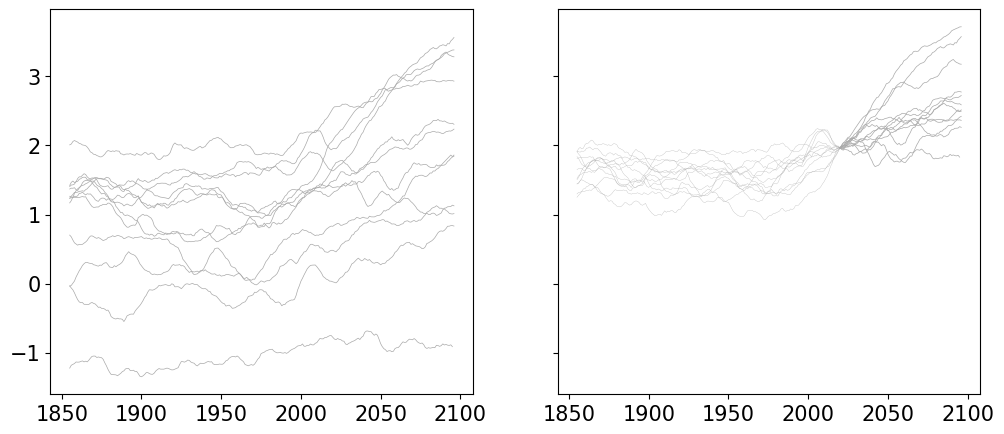

In [34]:

# ── plot ──────────────────────────────────────────────────────────────────────

GREY       = 'darkgrey'
MEAN_COLOR = 'grey'
UKESM_IDX  = -3   # index of UKESM1 in the loaded list
CESM_IDX   = -1   # index of CESM2-WACCM in the loaded list

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

# Individual ensemble members (both panels)
for da_raw, da_bef, da_aft in zip(ihtds_raw, ihtds_before, ihtds_after):
    axes[0].plot(da_raw.year,  da_raw,  color=GREY, linewidth=0.5)
    axes[1].plot(da_bef.year,  da_bef,  color=GREY, linewidth=0.2)
    axes[1].plot(da_aft.year,  da_aft,  color=GREY, linewidth=0.5)

# Ensemble mean
axes[0].plot(ens_mean.year,        ens_mean,        color=MEAN_COLOR, linewidth=3)
axes[1].plot(ens_mean_before.year, ens_mean_before, color=MEAN_COLOR, linewidth=3)
axes[1].plot(ens_mean_after.year,  ens_mean_after,  color=MEAN_COLOR, linewidth=3)

# UKESM1
da,lw = ihtds_raw[UKESM_IDX],2
axes[0].plot(da.year, da,  color='mediumblue', linewidth=lw)
da,lw = ihtds_before[UKESM_IDX], 0.5
axes[1].plot(da.year, da,  color='mediumblue', linewidth=lw)
da,lw = ihtds_after[UKESM_IDX], 2
axes[1].plot(da.year, da,  color='mediumblue', linewidth=lw)

# CESM2
da,lw = ihtds_raw[CESM_IDX],2
axes[0].plot(da.year, da,  color='green', linewidth=lw)
da,lw = ihtds_before[CESM_IDX], 0.5
axes[1].plot(da.year, da,  color='green', linewidth=lw)
da,lw = ihtds_after[CESM_IDX], 2
axes[1].plot(da.year, da,  color='green', linewidth=lw)

# ERA5 (both panels)
for ax in axes:
    ax.plot(ihtd_era5_10.year, ihtd_era5_10.t2m, color='firebrick', linewidth=2)

# Legend handles (dummy plots with correct style for each series)
h_era5  = axes[0].plot([], [], color='firebrick',     linewidth=2,   label='ERA5')[0]
h_ukesm = axes[0].plot([], [], color='mediumblue',  linewidth=2,   label='UKESM1')[0]
h_cesm  = axes[0].plot([], [], color='green',       linewidth=2,   label='CESM2-WACCM')[0]
h_mean  = axes[0].plot([], [], color=MEAN_COLOR,    linewidth=3,   label='Multi-model mean')[0]
h_ens   = axes[0].plot([], [], color=GREY,          linewidth=0.5, label='Individual models')[0]

# Formatting
axes[0].set_title('(a) IHTD: Absolute')
axes[1].set_title('(b) IHTD: Bias-corrected to present ERA5')
for ax in axes:
    ax.set_xlabel('Year')
    ax.set_xlim([1850, 2100])
    ax.grid(lw=0.07, c='black')
    ax.legend(handles=[h_era5, h_ukesm, h_cesm, h_mean, h_ens],
              loc='lower right', ncol=1, fontsize=10)
axes[0].set_ylabel('IHTD (°C)')

plt.tight_layout()
plt.savefig('Final_figures/Fig1.jpg', dpi=350)


In [ ]:
ITDs_mean = ihtds_raw

warmings =[]
injs = []

# from CIDER notebook - sensitivity (IHTD reduction per Tg of 60N SAI):
# UKESM AH, CESM AH, UKESM AL, CESM AL values:
# 0.1316619594139899 0.11273689785573632 0.1354072795465053 0.11273698120638048
sensitivity = 0.123
inj_start = 2035


for i in range(len(ITDs_mean)):
    post_start = ITDs_mean[i].sel(year = slice(inj_start, 2095)) # to 2095 cause CCCR-IITM has one less year... 
    base_2035 = ITDs_mean[i].sel(year= inj_start)
    warming = post_start - base_2035
    warmings.append(warming)
    inj = warming / sensitivity
    injs.append(inj)

In [ ]:
inj_list = [i.values for i in injs]

p05 = np.percentile(inj_list, 5, axis=0)
p25 = np.percentile(inj_list, 25, axis=0)
p50 = np.percentile(inj_list, 50, axis=0)
p75 = np.percentile(inj_list, 75, axis=0)
p95 = np.percentile(inj_list, 95, axis=0)

x = np.arange(len(p50))
# best fit through origin:
slope = np.sum(x * p50) / np.sum(x**2)
y_fit = slope * x
slope

In [ ]:

plt.figure(figsize=(10, 5))

h1 = plt.fill_between(injs[0].year, p05, p95, color='lightgray', alpha=0.4, label='5–95 percentile range')

# 25–75% range (darker fill)
h2 = plt.fill_between(injs[0].year, p25, p75, color='gray', alpha=0.6, label='25–75 percentile range')

# slope 
h3 = plt.plot(injs[0].year, y_fit, color='black', ls = '--', lw = 1,label='Linear best fit')[0] #\n (slope = 0.73)')

# Median line '#134760'
m = plt.plot(injs[0].year, p50, color='dimgray', linewidth=3, label='Median')[0]

u = plt.plot(injs[-3].year, injs[-3], color = 'mediumblue', lw = 1, label = 'UKESM1')[0]
c = plt.plot(injs[-1].year, injs[-1], color = 'green', lw = 1, label = 'CESM2-WACCM')[0]

# --- Style tweaks ---
plt.xlabel('Year')
plt.ylabel(f'Injection amount at 60N (Mt/yr)')
plt.title(f'Arctic-only SAI consistent with holding IHTD at {inj_start} levels')
plt.legend(handles = [h1, h2, m, h3, u, c], fontsize = 11)
plt.xlim(2030,2100)

plt.grid(lw = 0.1, c = 'black')

plt.tight_layout()

plt.savefig('Final_figures/Fig3.jpg', dpi=350)
plt.show()